# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

m +/- sigma_m = 2.4087 +/- 0.11232
b +/- sigma_b = 26.27835 +/- 0.64904


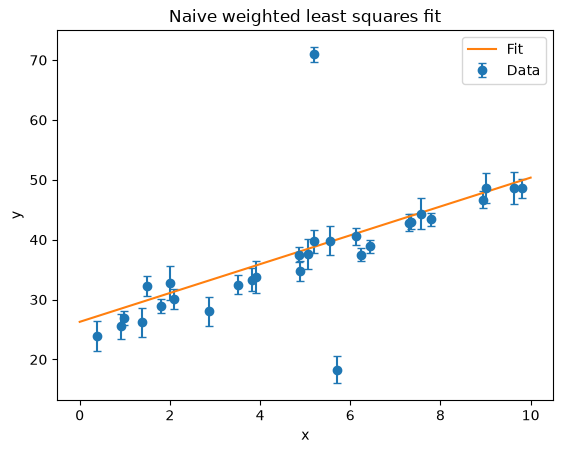

The reduced chi squared is 30.48652


In [31]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("../../labs/01/data/ratchev2.csv", delimiter = ",", skiprows = 1)
x = data[:,0]
y = data[:, 1]
y_sigma = data[:,2]

least_sqr, cov = np.polyfit(x, y, 1, w = 1 / y_sigma, cov = "unscaled")
m, b = least_sqr
m_sigma, b_sigma = np.sqrt(np.diag(cov))

print("m +/- sigma_m =", round(m, 5), "+/-", round(m_sigma, 5))
print("b +/- sigma_b =", round(b, 5), "+/-", round(b_sigma, 5))

x_vals_fit = np.linspace(0,10, 500)

plt.errorbar(x, y, yerr = y_sigma, fmt='o', label = "Data", capsize = 3)
plt.plot(x_vals_fit, m * x_vals_fit + b, label = "Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Naive weighted least squares fit")
plt.legend()
plt.show()

residuals = y - (m * x + b)
chi2_red = np.sum((residuals / y_sigma)**2) / (len(x) - 2)
print("The reduced chi squared is", round(chi2_red, 5))

**ANSWER (a few sentences):**

*This reduced chi squared of 30.5 is very high compared to the value you want for a good fit of close to 1. This high of a chi squared value is telling me that the data (along with the reported uncertainties of the data) is not represented by the model, either because there is a bad fit, underestimated uncertainties, or both. It is telling me this because there are obvious outliers far from the fitted line with very small error bars relative to their distance from the fit (this results in large chi squared contributions since residuals are large while sigma is small), and additionally the clear outliers are pulling the fitted line away from the main trend which results in other points that may not be outliers having error bars that the fitted line does not pass through. In addition to this, judging from the plot many points still appear to have underestimated error bars in comparison with the actual spread of the data, which further raised the reduced chi squared. I would not trust these error bars on the fitted slope and the intercept (both of which are relatively small in the context of the model's lack of good fit) because the least squares fit assumes Gaussian uncertainties and can't possibly account for outliers that break this assumption.*

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

Sigma clipping: m +/- sigma_m = 2.43025 +/- 0.11236
Sigma clipping: b +/- sigma_b = 24.5788 +/- 0.65327
Sigma clipping: reduced chi squared = 0.92319


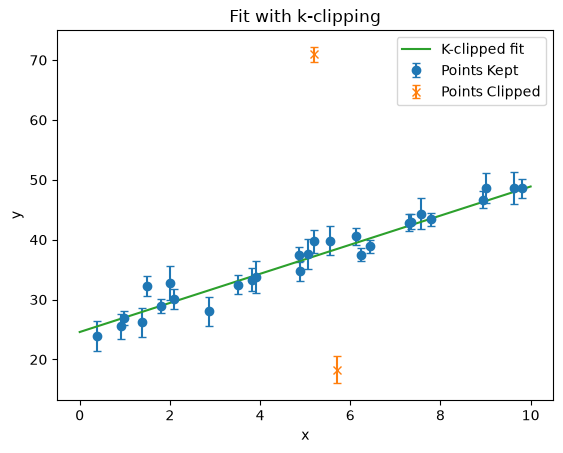

Mixture model: m +/- sigma_m = 2.43819 +/- 0.10194
Mixture model: b +/- sigma_b = 24.52919 +/- 0.65565
Mixture model: Outlier Fraction = 0.07856 +/- 0.42376


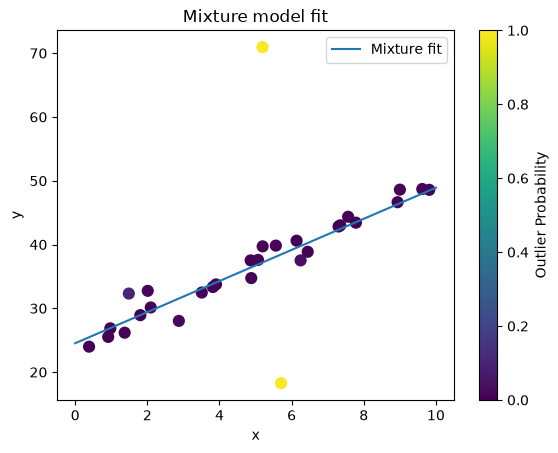

In [33]:
# Part 2: your work here

# sigma clipping
def sigma_clipping(x, y, sigma, k, iteration_lim):
    clip_mask = np.full(len(x), True)
    for i in range(iteration_lim):
        curr_fit, cov = np.polyfit(x[clip_mask], y[clip_mask], 1, w = 1 / sigma[clip_mask], cov = 'unscaled')
        m, b = curr_fit
        residuals = y - (m  * x + b)
        new_mask = np.abs(residuals / sigma) < k
        
        break_out = True
        for j in range(len(clip_mask)):
            if (clip_mask[j] != new_mask[j]):
                break_out = False
                break
        if (break_out):
            break
            
        clip_mask = new_mask
    return clip_mask

# I chose to use k = 3 as the threshold for the clipping because it removes the 2 very clear outliers while keeping points where it is less clear if they are outliers or not.
# The two obvious outliers are far enough away from the fit that they are still removed with k = 9, while using k = 2 removes two points closer to the main trend that could
# plausibly be good points and just be on the end of the bell curve. Therefore, I decided to use k = 3 as it removes the clear outliers without risking potentially removing good data.
sigma_mask = sigma_clipping(x, y, y_sigma, 3, 10)
final_fit, final_cov = np.polyfit(x[sigma_mask], y[sigma_mask], 1, w = 1 / y_sigma[sigma_mask], cov = 'unscaled')
m_mask, b_mask = final_fit
sigma_m_mask, sigma_b_mask = np.sqrt(np.diag(final_cov))

print("Sigma clipping: m +/- sigma_m =", round(m_mask, 5), "+/-", round(sigma_m_mask, 5))
print("Sigma clipping: b +/- sigma_b =", round(b_mask, 5), "+/-", round(sigma_b_mask, 5))

residuals_mask = y[sigma_mask] - (m_mask * x[sigma_mask] + b_mask)
chi2_red_k = np.sum((residuals_mask / y_sigma[sigma_mask])**2) / (len(x[sigma_mask]) - 2)

print("Sigma clipping: reduced chi squared =", round(chi2_red_k, 5))

x_vals_fit = np.linspace(0,10, 500)

plt.errorbar(x[sigma_mask], y[sigma_mask], yerr = y_sigma[sigma_mask], fmt='o', label = "Points Kept", capsize = 3)
plt.errorbar(x[~sigma_mask], y[~sigma_mask], yerr = y_sigma[~sigma_mask], fmt='x', label = "Points Clipped", capsize = 3)
plt.plot(x_vals_fit, m_mask * x_vals_fit + b_mask, label = "K-clipped fit")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Fit with k-clipping")
plt.legend()
plt.show()

# mixture model

from scipy.optimize import minimize
from scipy.stats import norm

def mix_likelihood(z0, x, y, sigma_y):
    m, b, p_bad, y_bad, log_V_bad = z0
    p_bad = np.clip(p_bad, 1e-6, 1 - 1e-6)
    good_term = (1 - p_bad) * norm.pdf(y, loc = (m * x + b), scale = sigma_y)
    bad_term = p_bad * norm.pdf(y, loc = y_bad, scale = np.sqrt(np.exp(log_V_bad) + sigma_y**2))
    return -np.sum(np.log(good_term + bad_term + 1e-300))

z0 = [m_mask, b_mask, 2/30, 40, np.log(50.0)] #I decided to start here from the k-clipped result as a decent initial guess, similar as in class
m_mix, b_mix, p_bad_mix, y_bad_mix, log_V_bad_mix = minimize(mix_likelihood, z0, args=(x, y, y_sigma), method='Nelder-Mead').x

# I need uncertainties on these values that I dont get as easily as with polyfit so I used the bootstrap method from class
# (with specfic seed so it does not change every time I load the cell)
r_num = np.random.default_rng(100000)
boot_num = 1500

m_boot_arr = np.empty(boot_num)
b_boot_arr = np.empty(boot_num)
p_bad_boot_arr = np.empty(boot_num)
for i in range(boot_num):
    random_idxs = r_num.integers(0, len(x), size = len(x))
    m_boot, b_boot, p_bad_boot, y_bad_boot, log_V_bad_boot = minimize(mix_likelihood, z0, args = (x[random_idxs], y[random_idxs], y_sigma[random_idxs]), method = 'Nelder-Mead').x
    m_boot_arr[i] = m_boot
    b_boot_arr[i] = b_boot
    p_bad_boot_arr[i] = p_bad_boot
m_mix_sigma = np.std(m_boot_arr)
b_mix_sigma = np.std(b_boot_arr)
p_bad_mix_sigma = np.std(p_bad_boot_arr)

print("Mixture model: m +/- sigma_m =", round(m_mix, 5), "+/-", round(m_mix_sigma, 5))
print("Mixture model: b +/- sigma_b =", round(b_mix, 5), "+/-", round(b_mix_sigma, 5))
print("Mixture model: Outlier Fraction =", round(p_bad_mix, 5), "+/-", round(p_bad_mix_sigma, 5))

good_term = (1 - p_bad_mix) * norm.pdf(y, loc = (m_mix * x + b_mix), scale = y_sigma)
bad_term = p_bad_mix * norm.pdf(y, loc = y_bad_mix, scale = np.sqrt(np.exp(log_V_bad_mix) + y_sigma**2))
p_bad_point = bad_term / (good_term + bad_term)


plt.plot(x_vals_fit, m_mix * x_vals_fit + b_mix, label='Mixture fit')
plt.scatter(x, y, c = p_bad_point, s = 60, vmin=0, vmax=1)
plt.colorbar(label='Outlier Probability')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Mixture model fit')
plt.show()

**FINAL ANSWER:** $m = $ 2.43819 $\pm$ 0.10194 , $b = $ 24.52919 $\pm$ 0.65565 , outlier fraction $\approx$ 0.07856

**Justification and uncertainty method (a short paragraph):**

*The two models give very consistent values for m and b, as well as similar uncertainties for said values, however I would side with the mixture model. My reasoning behind this choice is that while with sigma-clipping you have to make the choice of a k value yourself which can remove a different amount of outliers based on that choice, the mixture model considers every point in its final fit and instead assigns them all a probability of being good points. This means there is no explanation needed for an arbitrary cutting threshold. I estimated my final uncertainties using a bootstrap method with 1500 runs with resampled data, taking the standard deviation of the recomputed fit parameters in each run. I believe these values since this method makes no assumptions about the distribution and computes the intervals of the parameters which is exactly how the uncertainty is defined. One thing to note is that there is a relatively large uncertainty on the outlier fraction I calculated with the bootstrap method. However, this is likely caused by the resampling of the bootstrap method having some bootstrap samples with only one outlier or no outliers which heavily impacts this fraction. The uncertainties on m and b however are much more trustworthy because they are constrained by a much larger number of points following the main trend, and are consistent with sigma clipping results.*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1: In the initial fit, the AI solution does not use the uncertainties on y that are included in the input file (sigma_y). It instead just treats every point as having an equal uncertainty which is blatantly wrong as the dataset provides unique uncertainty values for each y point. This results in the calculated uncertainties for the slope and intercept being much higher (along with different values for the slope and intercept themselves) as seen in the demonstration. Trying to do the analysis with this flaw results in the AI not clipping one of the outliers for the 3-sigma k-clipping because of these overestimated uncertainties. So, as seen in the demonstration of this flaw below, this results in not only wrong naive fit values and uncertainties but down the line problems with further outlier analysis. The correct treatment is as I have shown in Part 1 (and the start of part 2), which is to use the given uncertainties and use the corresponding weights in the algorithm as well as in the k-clipping calculation*

*Flaw 2: The AI only does the sigma clipping with one iteration rather than iteratively. This is a problem because in the current dataset, the two obvious outliers are included when calculating the initial fit and so they pull the line away from the main trend. This allows the residuals of legitimate points to become larger enough to exceed 3 sigma and get clipped. After the two obvious outliers are removed, the fit moves closer to the main population and the residual of the legitimate point shrinks to below 3 sigma and so it is kept by the iterative procedure. We can see this on display in Demonstration 2 where I take my code (not the AI code) and cap the k-sigma clipping at one iteration, and it ends up removing a point that is legitimate as a result for the reason described above (compare to my Part 2 sigma clipping where this point is not removed). The correct treatment is to increase the number of iterations in order to allow for the k-sigma clipping to converge on a set of points where no more clipping occurs for the given k.*

*Flaw 3: The AI artificially multiplies all of the measurement uncertainties as well the final fitted uncertainties by the square root of chi squared in order to force chi-squared to be one, which it then uses to conclude that the fit and data are consistent. This is circular reasoning that effectively silences the warning signs of the chi squared value and claims that it was just underestimation of measurement uncertainties that was the problem without actually taking out the root cause of the problem which is the outliers. In my sigma-clipped fit, the reduced chi squared is 0.923 (close enough to 1) without having to rescale any uncertainties, which suggests that this AI rescaling step is not needed. Demonstration 3 shows the AI plot of the kept data after sigma clipping with the rescaled measurement uncertainties, and also prints out the final fit parameters with their uncertainties. We can clearly see visually in the plot that these error bars are not at all representative of the data, and we can see that the final fit parameters have uncertainties half an order of magnitude above my own values. This is also supported by the fact that there is still an outlier in the data and yet the model is claiming a chi-squared of 1 and therefore a consistent fit, while that is visibly not what is occuring as a problematic point is still there. The correct treatment here is to not rescale the measurement uncertainties, and instead take the high chi-squared value to mean there is still a problem with the data or the model, and use this info to find the remaining outlier using correct sigma-clipping, the mixture model, or some other method.*

BELOW IS THE DEMONSTRATION OF FLAW 1

AI Naive Slope:     m = 2.4952 +/- 0.5073
AI Naive Intercept: b = 24.9055 +/- 2.8573
AI Removed 1 outliers of 30 points
My Naive Slope:     m = 2.4087 +/- 0.1123
My Naive Intercept: b = 26.2784 +/- 0.6490


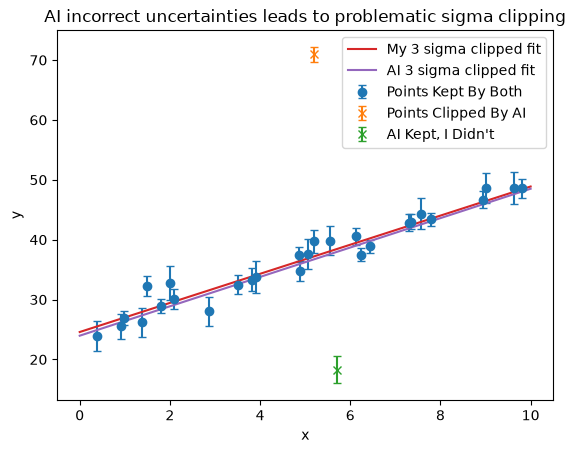

BELOW IS THE DEMONSTRATION OF FLAW 2

Sigma clipping (one clip): m +/- sigma_m = 2.46229 +/- 0.11323
Sigma clipping (one clip): b +/- sigma_b = 24.62443 +/- 0.65357
Sigma clipping (one clip): reduced chi squared = 0.75005


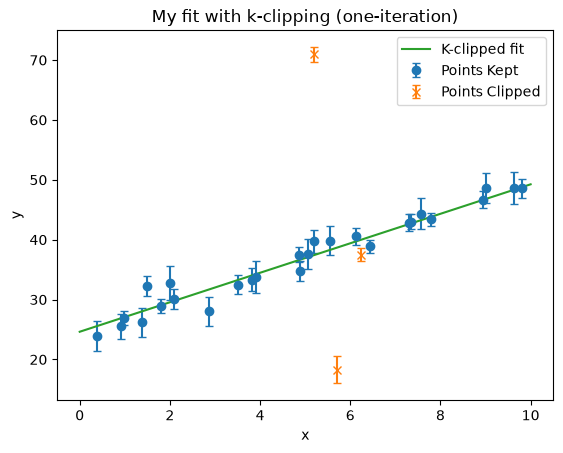

BELOW IS THE DEMONSTRATION OF FLAW 3



In [ ]:
# Part 3: demonstrations here

# DEMONSTRATION OF FLAW 1
print("BELOW IS THE DEMONSTRATION OF FLAW 1")
print("")
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt(f'../../labs/01/data/ratchev2.csv', delimiter=',', names=True)
x, y, sigma_y = data['x'], data['y'], data['sigma_y']
coeffs, cov = np.polyfit(x, y, 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))
residuals = y - (m_fit * x + b_fit)
threshold = 3 * np.std(residuals)
mask = np.abs(residuals) < threshold

print(f"AI Naive Slope:     m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"AI Naive Intercept: b = {b_fit:.4f} +/- {b_err:.4f}")
print(f"AI Removed {np.sum(~mask)} outliers of {len(x)} points")

print(f"My Naive Slope:     m = {m:.4f} +/- {m_sigma:.4f}")
print(f"My Naive Intercept: b = {b:.4f} +/- {b_sigma:.4f}")

coeffs, cov = np.polyfit(x[mask], y[mask], 1, cov=True)
m_fit, b_fit = coeffs
m_err, b_err = np.sqrt(np.diag(cov))

x_vals_fit = np.linspace(0,10, 500)

plt.errorbar(x[sigma_mask & mask], y[sigma_mask & mask], yerr = y_sigma[sigma_mask & mask], fmt='o', label = "Points Kept By Both", capsize = 3)
plt.errorbar(x[~mask], y[~mask], yerr = y_sigma[~mask], fmt='x', label = "Points Clipped By AI", capsize = 3)
plt.errorbar(x[~sigma_mask & mask], y[~sigma_mask & mask], yerr = y_sigma[~sigma_mask & mask], fmt='x', label = "AI Kept, I Didn't", capsize = 3)
plt.plot(x_vals_fit, m_mask * x_vals_fit + b_mask, label = "My 3 sigma clipped fit")
plt.plot(x_vals_fit, m_fit * x_vals_fit + b_fit, label = "AI 3 sigma clipped fit")
plt.xlabel('x')
plt.ylabel('y')
plt.title("AI incorrect uncertainties leads to problematic sigma clipping")
plt.legend()
plt.show()

# DEMONSTRATION OF FLAW 2
print("BELOW IS THE DEMONSTRATION OF FLAW 2")
print("")
sigma_mask_demo = sigma_clipping(x, y, y_sigma, 3, 1)
final_fit_demo, final_cov_demo = np.polyfit(x[sigma_mask_demo], y[sigma_mask_demo], 1, w = 1 / y_sigma[sigma_mask_demo], cov = 'unscaled')
m_mask_demo, b_mask_demo = final_fit_demo
sigma_m_mask_demo, sigma_b_mask_demo = np.sqrt(np.diag(final_cov_demo))

print("Sigma clipping (one clip): m +/- sigma_m =", round(m_mask_demo, 5), "+/-", round(sigma_m_mask_demo, 5))
print("Sigma clipping (one clip): b +/- sigma_b =", round(b_mask_demo, 5), "+/-", round(sigma_b_mask_demo, 5))

residuals_mask_demo = y[sigma_mask_demo] - (m_mask_demo * x[sigma_mask_demo] + b_mask_demo)
chi2_red_k_demo = np.sum((residuals_mask_demo / y_sigma[sigma_mask_demo])**2) / (len(x[sigma_mask_demo]) - 2)

print("Sigma clipping (one clip): reduced chi squared =", round(chi2_red_k_demo, 5))

x_vals_fit = np.linspace(0,10, 500)

plt.errorbar(x[sigma_mask_demo], y[sigma_mask_demo], yerr = y_sigma[sigma_mask_demo], fmt='o', label = "Points Kept", capsize = 3)
plt.errorbar(x[~sigma_mask_demo], y[~sigma_mask_demo], yerr = y_sigma[~sigma_mask_demo], fmt='x', label = "Points Clipped", capsize = 3)
plt.plot(x_vals_fit, m_mask_demo * x_vals_fit + b_mask_demo, label = "K-clipped fit")
plt.xlabel('x')
plt.ylabel('y')
plt.title("My fit with k-clipping (one-iteration)")
plt.legend()
plt.show()

# DEMONSTRATION OF FLAW 3
print("BELOW IS THE DEMONSTRATION OF FLAW 3")
print("")

chi2 = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_y[mask])**2)
dof = mask.sum() - 2
chi2_red = chi2 / dof

scale = np.sqrt(chi2_red)
sigma_scaled = sigma_y * scale
chi2_new = np.sum(((y[mask] - (m_fit * x[mask] + b_fit)) / sigma_scaled[mask])**2) / dof
m_err, b_err = m_err * scale, b_err * scale

plt.errorbar(x[mask], y[mask], yerr = sigma_scaled[mask], fmt='o', label = "Points Kept By AI", capsize = 3)
plt.plot(x_vals_fit, m_fit * x_vals_fit + b_fit, label = "AI 3 sigma clipped fit")
plt.xlabel('x')
plt.ylabel('y')
plt.title("AI incorrect uncertainty rescaling leads to huge incorrect error bars on points and final parameters")
plt.legend()
plt.show()

print("Final results:")
print(f"  m = {m_fit:.4f} +/- {m_err:.4f}")
print(f"  b = {b_fit:.4f} +/- {b_err:.4f}")

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

*I didn't use any, I prefered to do stuff by myself (and look up documentation for numpy, matplotlib, etc when needed). There was no major time intensive part of this that would be mundane and so I did not find AI necessary.*

**VERIFICATION PLAN:**

*I did a few different personal checks before deciding to trust my Part 2 numbers. For one, I looked at the new chi_2 of the sigma clipped fit (which was 0.923) and confirmed that it was close to 1, which suggests that the stated measurement uncertainties are consistent with the scatter of the remaining points about the fit. A failure would have looked like a large reduced chi squared after removing the outliers, which would suggest that the model is still not correct or the uncertainty estimates were not correct (in that case I was prepared to use MAD sigma). I also compared the sigma-clipping and mixture-model results, and got very similar values for the m and b parameters, which suggests the method used to handle the outliers doesn't strongly influence my results. A failure would have been a significant difference between the two models. Similarly, I checked that the mixture-model probabilities confirmed the same outliers clipped by the sigma clipping, for the same reason as above. A failure would have been higher probabilities of bad points on non-clipped k-sigma points or the other way around. I also plotted the residuals before and after the clipping of outliers to confirm that the very obvious outliers were the ones getting removed and that the fit wasn't removing anything within the k-sigma bound. A failure here would have been a point removal that was within the k-sigma bound or a point not being removed despite being having a residual larger than k sigma (I did however have to be careful here since the residuals change after every iteration of the clip, so I plotted the residuals for each iteration. This is not in my code above due to the large amount of clutter it caused but I did apply such checks). Lastly, for the mixture model, I ran some sanity checks on my parameters by printing the final parameters out for a bunch of different random seeds in the bootstrap method. I checked that the probability of a bad point was between 0 and 1 and that V_bad was positive, as they must be by definition, and that the parameters stayed reasonably consistent across runs. A failure would have been if V_bad was negative or the probability was not between 0 and 1, or there was a lack of consistency in my bootstrap final parameters.* 
